In [2]:
import pandas as pd
from collections import Counter
import numpy as np
from scipy.stats import entropy

In [3]:
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results

In [4]:
group_var_dict = {"V201549x" : "Race", 'V202022' : "Discuss Politics", 'V201200' : "Ideology", 'V201231x' : "Party", 
                  'V201452' : "Church", 'V201600' : "Gender", 'V202406' : "Political Interest"}

groups = {
    'V201549x': {1: 'White', 2: 'Black', 3: 'Asian', 4: 'Native American', 5: 'Hispanic'},
    'V202022': {
            1: 'Like to discuss politics with my family and friends.',
            2: 'Never discuss politics with my family or friends.'
            },
    'V201200': {
            1: "Liberal",
            2: "Liberal",
            3: "Liberal",
            4: "Moderate",
            5: "Conservative",
            6: "Conservative",
            7: "Conservative"
        },
    'V201231x': {
            1: "Democrat",
            2: "Democrat",
            3: "Independent",
            4: "Independent",
            5: "Independent",
            6: "Republican",
            7: "Republican"
        },
    'V201452': {1: "Attend church", 2: "Does not attend church"},
    'V201600': {1: "Man", 2: "Woman"},
}

In [5]:
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}

groups_keys = groups.keys()

def get_counts_group(path, qids, key): #function to get a dict with counts for each question

    value_list = {}

    for number, group in groups[key].items():

        value_list[group] = []

        for id in qids:
            df = pd.read_csv(path + id + ".csv")
            df_group = df[df[key] == number]

            df_group.loc[:, 'Response'] = pd.to_numeric(df_group['Response'], errors='coerce')     
            value_counts = Counter(df_group['Response'].dropna())

            if id in ["V201324", "V202332"]:

                answers = {i: value_counts[i] for i in range(1, 6)}
            else:
                answers = {i: value_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

In [6]:
def get_human_counts_group(path, qids, key): #getting results from anes 2020
     
    value_list = {}

    for number, group in groups[key].items():

        value_list[group] = []

        df = pd.read_csv(path)

        df_group = df[df[key] == number]

        for id in qids:

            human_counts = Counter(df_group[id].dropna())

            if id in ["V201324", "V202332"]:

                answers = {i: human_counts[i] for i in range(1, 6)}
            else:
                answers = {i: human_counts[i] for i in range(1, 4)}

            value_list[group].append({name_dict[id] : answers})

    return value_list

#human_results = get_human_counts_group("data/2020 ANES_test.csv", qids)

In [ ]:
human_results_groups = {}
replicate_results_groups = {}
reformulated_results_groups = {}

for key in groups_keys:
    human_results_groups[group_var_dict[key]] = get_human_counts_group("data/2020 ANES_test.csv", qids, key)
    replicate_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_results/full_results_2020_", qids, key)
    reformulated_results_groups[group_var_dict[key]] = get_counts_group("Publication Results/GPT4.1/main_mq_reform_results/full_results_2020_", qids, key)

results = [human_results_groups, replicate_results_groups, reformulated_results_groups]    

In [8]:
replicate_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            replicate_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[1][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in replicate_jsd_groups}

replicate_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
replicate_jsd_groups_df.head(20)

replicate_jsd_groups_df['Average'] = replicate_jsd_groups_df.mean(axis=1)
replicate_jsd_groups_df = replicate_jsd_groups_df.sort_values('Average', ascending=False)

In [9]:
reformulated_jsd_groups = []

for key, value in results[0].items():
        for key_1 in results[0][key].keys():
            reformulated_jsd_groups.append({key_1: jsd_divergence_between_sets(results[0][key][key_1], results[2][key][key_1])})
            
dict_jsd = {list(d.keys())[0]: list(d.values())[0] for d in reformulated_jsd_groups}

reformulated_jsd_groups_df = pd.DataFrame.from_dict(dict_jsd, orient="index")
reformulated_jsd_groups_df.head(20)

reformulated_jsd_groups_df['Average'] = reformulated_jsd_groups_df.mean(axis=1)
reformulated_jsd_groups_df = reformulated_jsd_groups_df.sort_values('Average', ascending=False)

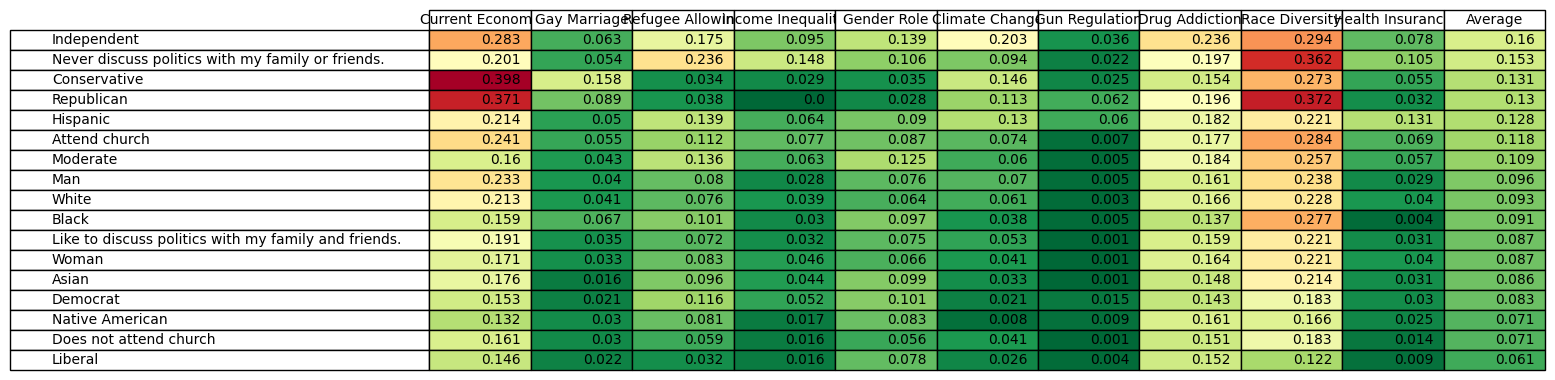

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3)) 

ax.axis("off")

table = ax.table(
    cellText=replicate_jsd_groups_df.round(3).values,
    colLabels=replicate_jsd_groups_df.columns,
    rowLabels=replicate_jsd_groups_df.index,
    loc="center"
)

cmap = plt.cm.RdYlGn_r 

vals = replicate_jsd_groups_df.values.flatten()
norm = (vals - vals.min()) / (vals.max() - vals.min())

i = 0
for r in range(replicate_jsd_groups_df.shape[0]):
    for c in range(replicate_jsd_groups_df.shape[1]):
        color = cmap(norm[i])
        table[(r+1, c)].set_facecolor(color) 
        i += 1

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()



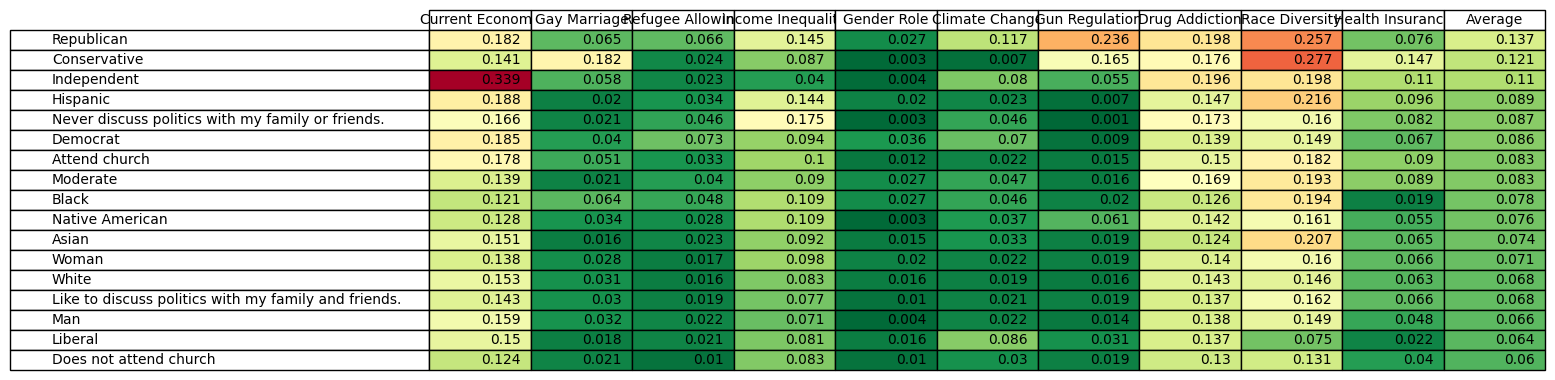

In [11]:
import matplotlib.pyplot as plt

# Make figure
fig, ax = plt.subplots(figsize=(12, 3))  # adjust height as needed

# Hide axes
ax.axis("off")

# Create table
table = ax.table(
    cellText=reformulated_jsd_groups_df.round(3).values,
    colLabels=reformulated_jsd_groups_df.columns,
    rowLabels=reformulated_jsd_groups_df.index,
    loc="center"
)


# 5. Apply value-based coloring
# Choose a colormap
cmap = plt.cm.RdYlGn_r  # green = high, red = low

# Normalize values between 0 and 1 for the colormap
vals = reformulated_jsd_groups_df.values.flatten()
norm = (vals - vals.min()) / (vals.max() - vals.min())

# Apply the colors cell-by-cell
i = 0
for r in range(reformulated_jsd_groups_df.shape[0]):
    for c in range(reformulated_jsd_groups_df.shape[1]):
        color = cmap(norm[i])
        table[(r+1, c)].set_facecolor(color)  # +1 because row 0 is header
        i += 1

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()



In [15]:
reformulated_vs_replicate_jsd_df = reformulated_jsd_groups_df.sort_index().sort_index(axis=1) - replicate_jsd_groups_df.sort_index().sort_index(axis=1)
reformulated_vs_replicate_jsd_df = reformulated_vs_replicate_jsd_df.sort_values('Average', ascending=False)


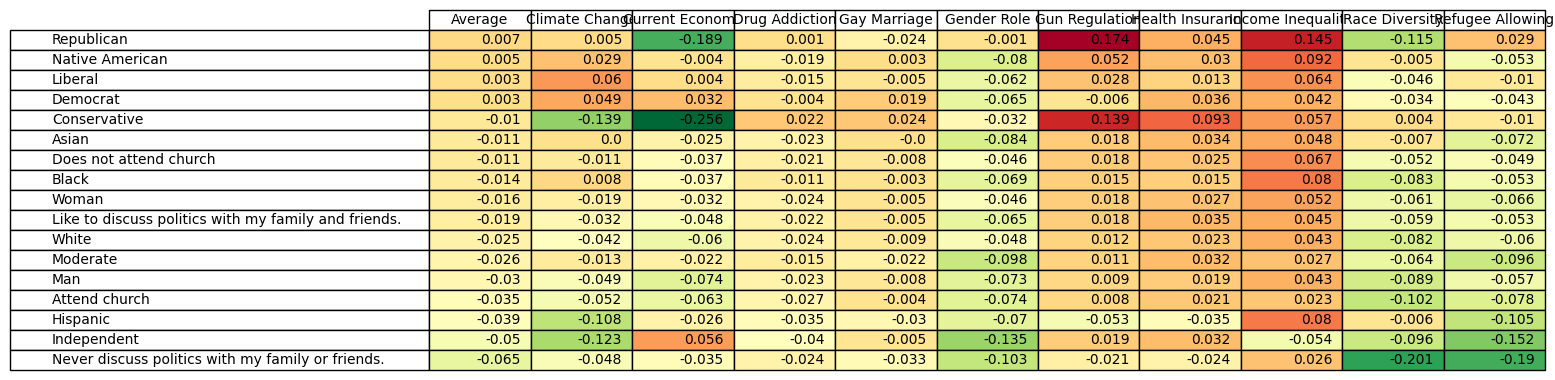

In [16]:
# Make figure
fig, ax = plt.subplots(figsize=(12, 3))  # adjust height as needed

# Hide axes
ax.axis("off")

# Create table
table = ax.table(
    cellText=reformulated_vs_replicate_jsd_df.round(3).values,
    colLabels=reformulated_vs_replicate_jsd_df.columns,
    rowLabels=reformulated_vs_replicate_jsd_df.index,
    loc="center"
)


# 5. Apply value-based coloring
# Choose a colormap
cmap = plt.cm.RdYlGn_r  # green = high, red = low

# Normalize values between 0 and 1 for the colormap
vals = reformulated_vs_replicate_jsd_df.values.flatten()
norm = (vals - vals.min()) / (vals.max() - vals.min())

# Apply the colors cell-by-cell
i = 0
for r in range(reformulated_vs_replicate_jsd_df.shape[0]):
    for c in range(reformulated_vs_replicate_jsd_df.shape[1]):
        color = cmap(norm[i])
        table[(r+1, c)].set_facecolor(color)  # +1 because row 0 is header
        i += 1

# Formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()

